# Análise da camada gold — impacto da COVID-19 nas internações (SP, 2020–2023)

Este é o notebook central da AV2. Ele consome as tabelas agregadas da **camada gold**
(geradas pelo `src/build_gold.py`) e responde, uma a uma, às perguntas de pesquisa,
com gráficos interativos e leitura crítica dos resultados.

**Pergunta central:**
> Como as ondas do COVID-19 impactaram o volume de internações e a mortalidade
> hospitalar no SUS-SP entre 2020 e 2023?

**Sub-perguntas (uma seção cada):**
1. Como evoluiu, mês a mês, o volume de internações por COVID?
2. A taxa de óbito hospitalar subiu durante os picos da pandemia?
3. O perfil da internação (permanência e UTI) mudou de uma onda para outra?
4. Quais grupos demográficos (sexo e faixa etária) foram mais afetados?

As figuras usam **Plotly**. Os mesmos gráficos, de forma interativa e reunidos em
um painel único, estão em `output/dashboard.html`, gerado ao final deste notebook.

## 0. Configuração do ambiente e carga da camada gold

In [1]:
import os
import sys
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import plotly.io as pio

# Renderiza as figuras como imagem estática nas saídas: assim elas aparecem
# também ao navegar o notebook no GitHub. O painel interativo fica no dashboard.html.
pio.renderers.default = 'png'

ROOT = Path(os.getcwd())
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

# Funções de figura reaproveitadas do construtor do dashboard (fonte única).
import build_dashboard as dash

GOLD = ROOT / 'data' / 'gold'
gold = {nome: pd.read_parquet(GOLD / f'{nome}.parquet') for nome in
        ['serie_mensal', 'ondas', 'perfil_covid_vs_outros',
         'demografia_covid', 'municipios_covid']}

print('Tabelas gold carregadas:')
for nome, df in gold.items():
    print(f'  {nome:24s} {df.shape[0]:>4} linhas x {df.shape[1]} colunas')

Tabelas gold carregadas:
  serie_mensal               48 linhas x 10 colunas
  ondas                       4 linhas x 8 colunas
  perfil_covid_vs_outros      2 linhas x 8 colunas
  demografia_covid           14 linhas x 5 colunas
  municipios_covid           20 linhas x 4 colunas


## 1. Evolução mensal das internações por COVID

A série mensal separa as internações por COVID (CID **B342**) das internações por
outros motivos. Os picos da curva vermelha desenham as ondas da pandemia em São Paulo.

Total de internações por COVID (2020-2023): 411,272
Mês de pico: 03/2021 com 45,180 internações


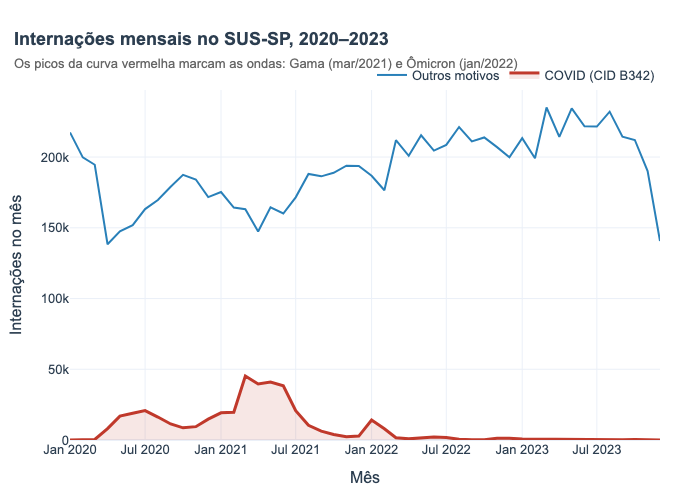

In [2]:
serie = gold['serie_mensal']
pico = serie.loc[serie['internacoes_covid'].idxmax()]
total_covid = int(serie['internacoes_covid'].sum())
print(f"Total de internações por COVID (2020-2023): {total_covid:,}")
print(f"Mês de pico: {pd.Timestamp(pico['ano_mes']).strftime('%m/%Y')} "
      f"com {int(pico['internacoes_covid']):,} internações")
dash.fig_serie_volume(serie)

**Leitura.** O volume de internações por COVID não é constante: ele se concentra em
três ondas bem marcadas. A primeira, ao longo de 2020 (vírus original), com pico em
julho. A segunda, no primeiro semestre de 2021 (variante Gama), foi a maior de todas,
chegando a **45.180 internações em março de 2021** — o pico de toda a série. A terceira,
em janeiro de 2022 (variante Ômicron), foi curta e intensa. A partir de meados de 2022,
a curva se achata e entra em regime endêmico. As internações por outros motivos (curva
azul) caem visivelmente no primeiro pico, em 2020, sinal do represamento de
procedimentos eletivos durante a fase mais aguda da pandemia.

## 2. Mortalidade hospitalar: a COVID frente aos demais motivos

Aqui a métrica deixa de ser contagem e passa a ser a **taxa de óbito hospitalar**: de
cada 100 internações, quantas terminaram em óbito, mês a mês.

Taxa de óbito hospitalar no período inteiro:
  COVID (B342):   23.0%
  Outros motivos: 5.5%
  Razão:          4.2x


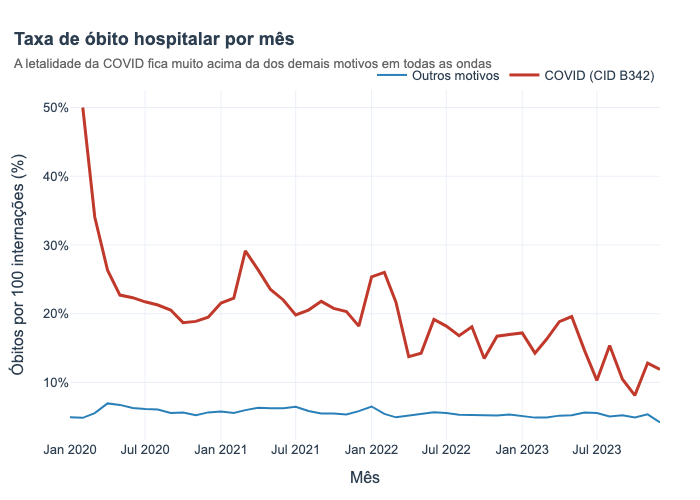

In [3]:
perfil = gold['perfil_covid_vs_outros'].set_index('grupo')
print("Taxa de óbito hospitalar no período inteiro:")
print(f"  COVID (B342):   {perfil.loc['COVID (B342)','taxa_obito']:.1f}%")
print(f"  Outros motivos: {perfil.loc['Outros motivos','taxa_obito']:.1f}%")
print(f"  Razão:          {perfil.loc['COVID (B342)','taxa_obito']/perfil.loc['Outros motivos','taxa_obito']:.1f}x")
dash.fig_serie_mortalidade(serie)

**Leitura.** A letalidade hospitalar da COVID fica **muito acima** da dos demais
motivos em praticamente todos os meses: **23,0% contra 5,5%** no período inteiro, uma
razão de cerca de **4,2 vezes**. A distância entre as curvas se abre justamente nos
picos das ondas, quando a pressão sobre os hospitais era maior. A taxa da COVID nos
primeiros meses de 2020 aparece instável porque o número de casos ainda era pequeno
(poucas internações no denominador).

## 3. Como o perfil das internações mudou de uma onda para outra

Esta seção compara as quatro janelas (Onda 1, Onda 2/Gama, Onda 3/Ômicron e período
endêmico) em três dimensões das internações por COVID: volume, letalidade e gravidade
(uso de UTI e dias de permanência).

onda,internacoes_covid,obitos_covid,taxa_obito_covid,dias_perm_medio,pct_com_uti,idade_media,val_medio_aih
Onda 1 (original),"101,195","22,212",21.9%,8.9,29.5%,59.2,"R$ 5,491"
Onda 2 (Gama),"268,482","63,281",23.6%,8.8,31.4%,56.2,"R$ 6,686"
Onda 3 (Ômicron),"29,589","7,089",24.0%,9.0,30.9%,62.4,"R$ 5,826"
Endêmico,"12,006","1,989",16.6%,8.6,16.7%,62.4,"R$ 1,610"


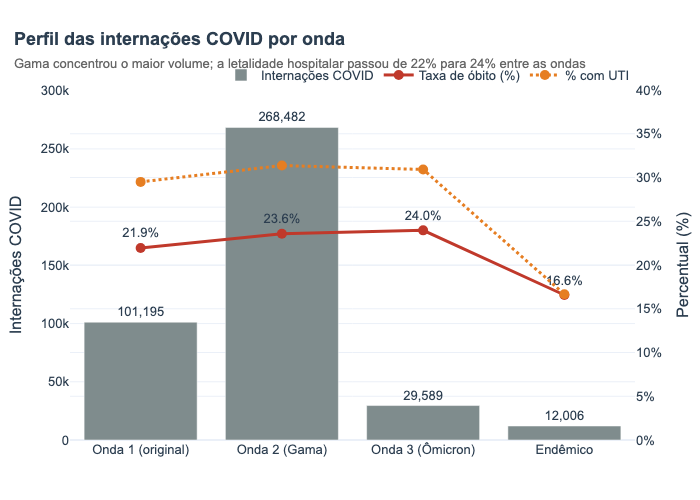

In [4]:
ondas = gold['ondas']
import pandas as pd
display(ondas.style.format({
    'internacoes_covid': '{:,.0f}', 'obitos_covid': '{:,.0f}',
    'taxa_obito_covid': '{:.1f}%', 'dias_perm_medio': '{:.1f}',
    'pct_com_uti': '{:.1f}%', 'idade_media': '{:.1f}', 'val_medio_aih': 'R$ {:,.0f}',
}).hide(axis='index'))
dash.fig_ondas(ondas)

**Leitura.** A **Onda 2 (Gama)** foi a mais pesada em volume: **268.482 internações
por COVID**, mais que o dobro da primeira onda. A letalidade hospitalar subiu de forma
contínua entre as ondas — **21,9% na Onda 1, 23,6% na Gama e 24,0% na Ômicron** — e o
uso de UTI ficou em torno de **30%** nas três. O período endêmico é o ponto de virada:
a letalidade cai para **16,6%** e o uso de UTI para **16,7%**, refletindo casos menos
graves, avanço da vacinação e mudança no perfil de quem interna. Os dias médios de
permanência permanecem estáveis (perto de 9 dias) em todas as fases agudas.

## 4. Quem foi mais afetado: faixa etária e sexo

Olhando apenas as internações por COVID, esta seção mostra a **taxa de óbito** por faixa
etária e sexo — ou seja, a gravidade do desfecho em cada grupo.

Grupo com maior letalidade: Masculino 75+ anos -> 40.1% de óbito


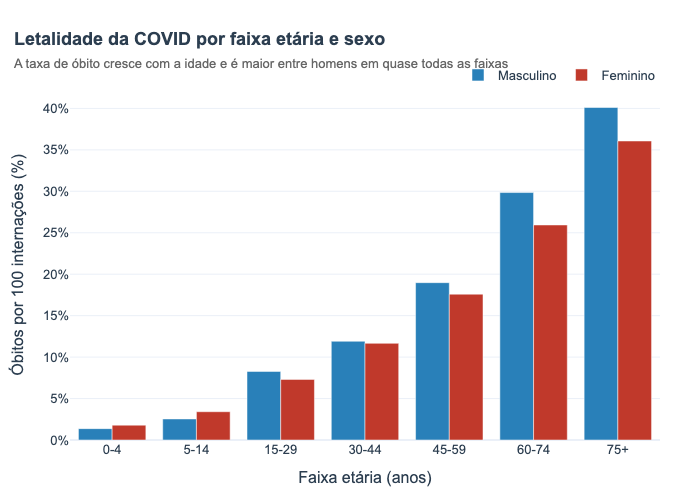

In [5]:
demo = gold['demografia_covid']
mais_letal = demo.loc[demo['taxa_obito'].idxmax()]
print(f"Grupo com maior letalidade: {mais_letal['sexo']} {mais_letal['faixa_etaria']} anos "
      f"-> {mais_letal['taxa_obito']:.1f}% de óbito")
dash.fig_demografia(demo)

**Leitura.** A letalidade da COVID **cresce de forma acentuada com a idade**: vai de
menos de 2% nas crianças a mais de 35% entre os idosos. O grupo mais atingido é o de
**homens com 75 anos ou mais, com 40,1% de óbito** — ou seja, duas em cada cinco
internações desse grupo terminaram em morte. Em quase todas as faixas, a taxa masculina
supera a feminina, padrão coerente com a literatura sobre maior gravidade da COVID em
homens.

## 5. Síntese do perfil clínico: COVID frente a outros motivos

Um retrato consolidado do quanto a internação por COVID se diferencia das demais.

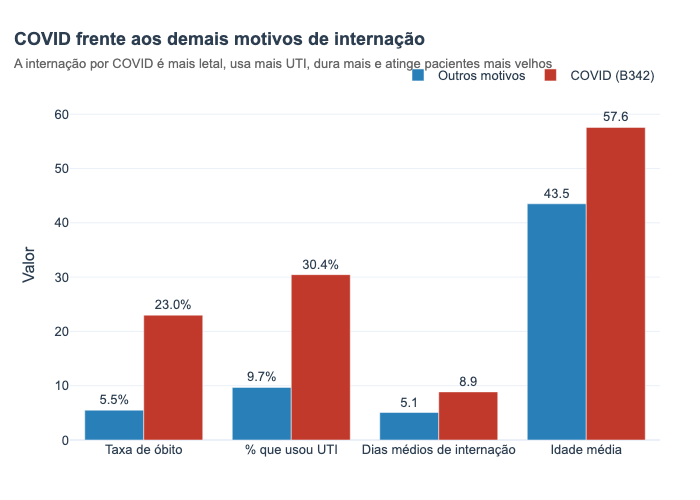

In [6]:
dash.fig_perfil(gold['perfil_covid_vs_outros'])

**Leitura.** A internação por COVID é, em todas as dimensões, mais grave: é **mais
letal** (23,0% vs 5,5%), **usa mais UTI** (30,4% vs 9,7%), **dura mais** (8,9 vs 5,1
dias em média) e atinge **pacientes mais velhos** (idade média de 57,6 vs 43,5 anos). O
valor médio da AIH também é bem maior, sinal do custo hospitalar mais alto desse tipo
de internação.

## 6. Concentração geográfica

Distribuição das internações por COVID entre os municípios de atendimento.

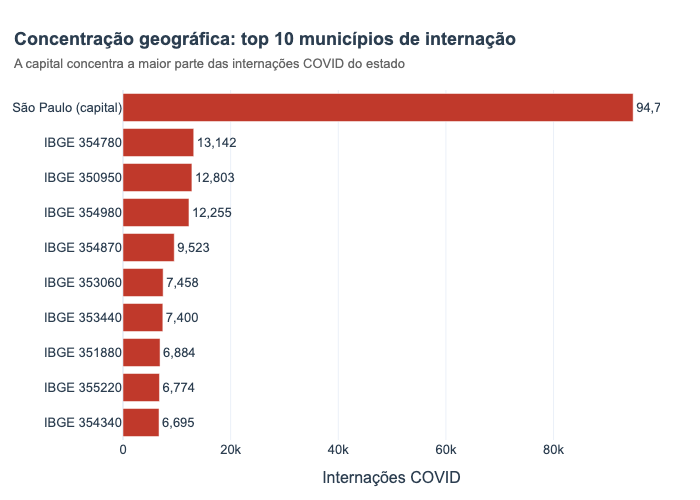

In [7]:
dash.fig_municipios(gold['municipios_covid'])

**Leitura.** As internações por COVID se concentram fortemente na **capital
(São Paulo, código IBGE 355030)**, que responde sozinha pela maior parte dos casos do
estado — coerente com a concentração da rede hospitalar de alta complexidade do SUS na
capital. Os demais municípios aparecem identificados pelo código IBGE.

## 7. Geração do dashboard interativo

A célula abaixo monta o painel único e interativo em `output/dashboard.html`. Esse é o
artefato usado na apresentação: abre em qualquer navegador, sem servidor, com todos os
gráficos acima de forma interativa (zoom, hover e filtro de séries).

In [8]:
caminho = dash.build_dashboard(
    gold_dir=ROOT / 'data' / 'gold',
    output=ROOT / 'output' / 'dashboard.html',
    figuras_dir=ROOT / 'output' / 'figuras',
)
print('Dashboard gerado em:', caminho)

22:59:34 [INFO] Tabelas gold carregadas: ['serie_mensal', 'ondas', 'perfil_covid_vs_outros', 'demografia_covid', 'municipios_covid']


22:59:36 [INFO] figura/01_serie_volume.png


22:59:38 [INFO] figura/02_serie_mortalidade.png


22:59:39 [INFO] figura/03_ondas.png


22:59:41 [INFO] figura/04_perfil.png


22:59:43 [INFO] figura/05_demografia.png


22:59:44 [INFO] figura/06_municipios.png


22:59:44 [INFO] Dashboard salvo em: /Users/claudio/Code/me/school/data/project/sus-analytics/output/dashboard.html (4787 KB)


Dashboard gerado em: /Users/claudio/Code/me/school/data/project/sus-analytics/output/dashboard.html


## Conclusões

- O impacto da COVID nas internações do SUS-SP foi **concentrado em ondas**, com pico
  absoluto em **março de 2021** (variante Gama).
- A doença foi **muito mais letal** no hospital que a média das demais internações
  (**23,0% vs 5,5%**) e exigiu **três vezes mais UTI**.
- A **gravidade aumentou da Onda 1 para a Ômicron** e só recuou no **período endêmico**,
  quando letalidade e uso de UTI caíram pela metade.
- O desfecho foi fortemente **etário e por sexo**: idosos, e em especial **homens com
  75+**, tiveram a maior letalidade (**40,1%**).
- O peso recaiu sobre a **capital**, que concentra a rede de alta complexidade.

**Limitações.** A base é administrativa (AIH) e cobre apenas internações pagas pelo SUS;
não inclui rede privada nem casos não internados. O CID B342 é o registro do SIH/SUS
para COVID e pode subnotificar casos codificados de outra forma. As janelas de onda são
uma convenção analítica baseada nos picos da própria série.